In [6]:
import pandas as pd
from feature_engine.imputation import MeanMedianImputer
from sklearn.pipeline import Pipeline


In [12]:
df = pd.DataFrame({
    "age": [23, 45, 56, None, 34, None, 40],
    "salary": [50000, 60000, None, 80000, None, 70000, 90000],
    "height": [5.5, 6.0, 5.8, 5.9, 6.1, 5.7, 6.2]
})
print(df)
print("START TRANSFORMATION")
imputer = MeanMedianImputer(imputation_method='median', variables=['age', 'salary', 'height'])
pipe = Pipeline([('imputer', imputer)])
pipe.fit(df)
dft=pipe.transform(df)
print(dft)

    age   salary  height
0  23.0  50000.0     5.5
1  45.0  60000.0     6.0
2  56.0      NaN     5.8
3   NaN  80000.0     5.9
4  34.0      NaN     6.1
5   NaN  70000.0     5.7
6  40.0  90000.0     6.2
START TRANSFORMATION
    age   salary  height
0  23.0  50000.0     5.5
1  45.0  60000.0     6.0
2  56.0  70000.0     5.8
3  40.0  80000.0     5.9
4  34.0  70000.0     6.1
5  40.0  70000.0     5.7
6  40.0  90000.0     6.2


In [ ]:
from feature_engine.imputation import CategoricalImputer

df = pd.DataFrame({
    "city": ["New York", "Los Angeles", None, "Chicago", "Houston", None, "Chicago"],
    "color": ["Red", None, "Blue", "Green", None, "Yellow", "Blue"]
})

print(df)
print("START TRANSFORMATION")
cat_imputer = CategoricalImputer(imputation_method='frequent', variables=['city', 'color'])
cat_imputer.fit(df).transform(df)

#Pipiline Example
""" pipe = Pipeline([('imputer', cat_imputer)]) 
pipe.fit(df)
dfdf=pipe.transform(df) 
print(dfdf) """

 

          city   color
0     New York     Red
1  Los Angeles    None
2         None    Blue
3      Chicago   Green
4      Houston    None
5         None  Yellow
6      Chicago    Blue
START TRANSFORMATION
          city   color
0     New York     Red
1  Los Angeles    Blue
2      Chicago    Blue
3      Chicago   Green
4      Houston    Blue
5      Chicago  Yellow
6      Chicago    Blue


In [21]:
from feature_engine.imputation import CategoricalImputer, RandomSampleImputer

df = pd.DataFrame({
    "city": ["New York", "Los Angeles", None, "Chicago", "Houston", None, "Chicago"],
    "color": ["Red", None, "Blue", "Green", None, "Yellow", "Blue"],
    "income": [70000, 80000, 75000, None, 90000, 85000, None]   
})

print(df)
print("START TRANSFORMATION")
cat_impute = CategoricalImputer(imputation_method='frequent', variables=['city', 'color'])
rand_impute = RandomSampleImputer(variables=['income'], random_state=42)

pipe = Pipeline(steps=[('cat_imputer', cat_impute), ('rand_imputer', rand_impute)])

df_imputed = pipe.fit_transform(df)
display(df_imputed)

          city   color   income
0     New York     Red  70000.0
1  Los Angeles    None  80000.0
2         None    Blue  75000.0
3      Chicago   Green      NaN
4      Houston    None  90000.0
5         None  Yellow  85000.0
6      Chicago    Blue      NaN
START TRANSFORMATION


,city,color,income
0,New York,Red,70000.0
1,Los Angeles,Blue,80000.0
2,Chicago,Blue,75000.0
3,Chicago,Green,90000.0
4,Houston,Blue,90000.0
5,Chicago,Yellow,85000.0
6,Chicago,Blue,85000.0


In [ ]:
#Build a small DataFrame and apply one hot encoding for cities {"New York", "Los Angeles", "Chicago", "Houston"}
from feature_engine.encoding import OneHotEncoder
df = pd.DataFrame({ 
    "city": ["New York", "Los Angeles", "Chicago", "Houston", "Chicago", "New York", "Houston"]
})      
print(df)
onehot_enc = OneHotEncoder(drop_last=True, variables=['city'])
df_onehot = onehot_enc.fit_transform(df)
display(df_onehot)
#Build a small DataFrame and apply mean encoding for cities {"New York", "Los Angeles", "Chicago", "Houston"} based on a target variable

In [ ]:
#Build a small DataFrame and apply ordinal encoding for education levels {"High School", "Bachelo", "Master", "PhD")
#from feature_engine.encoding import OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({ 
    "education": ["Bachelo", "Master", "PhD", "High School", "Master", "Bachelo", "PhD"]
})
print(df)
# Create the ordinal encoder with explicit mapping
categories = [["High School", "Bachelo", "Master", "PhD"]]

sklearn_enc = OrdinalEncoder(categories=categories)
df_sklearn = df.copy()
df_sklearn['education'] = sklearn_enc.fit_transform(df[['education']])
display(df_sklearn)


     education
0      Bachelo
1       Master
2          PhD
3  High School
4       Master
5      Bachelo
6          PhD


,education
0,1.0
1,2.0
2,3.0
3,0.0
4,2.0
5,1.0
6,3.0


In [29]:
#Build a small DataFrame and apply ordinal encoding for education levels {"High School", "Bachelo", "Master", "PhD")
# Manual mapping with pandas and using feature_engine
from feature_engine.encoding import OrdinalEncoder
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({ 
    "education": ["Bachelo", "Master", "PhD", "High School", "Master", "Bachelo", "PhD"]
})
print(df)
# Create the ordinal encoder with explicit mapping
education_mapping = {'High School': 1, 'Bachelo': 2, 'Master': 3, 'PhD': 4}
df_manual = df.copy()
df_manual['education'] = df_manual['education'].map(education_mapping)

print("Manually encoded DataFrame:")
display(df_manual)

     education
0      Bachelo
1       Master
2          PhD
3  High School
4       Master
5      Bachelo
6          PhD
Manually encoded DataFrame:


,education
0,2
1,3
2,4
3,1
4,3
5,2
6,4


In [ ]:
#Equal Frequency Discretisation
#Log Transformation
from feature_engine.transformation import LogTransformer
from feature_engine.discretisation import EqualFrequencyDiscretiser 

df = pd.DataFrame({
    'income': [30000, 45000, 60000, 75000, 90000, 120000, 150000]
})
display(df)
display("Log Transformation")
log_df = LogTransformer(variables=['income'])
log_df.fit_transform(df)
display(df)
display("Equal Frequency Discretisation")
discretiser = EqualFrequencyDiscretiser(q=3, variables=['income'])
discretiser.fit_transform(df)
display(df)


,income
0,30000
1,45000
2,60000
3,75000
4,90000
5,120000
6,150000


'Log Transformation'

,income
0,30000
1,45000
2,60000
3,75000
4,90000
5,120000
6,150000


'Equal Frequency Discretisation'

,income
0,30000
1,45000
2,60000
3,75000
4,90000
5,120000
6,150000


In [ ]:
#Topic 5: Discretisation Techniques Comparison


import pandas as pd
import numpy as np
from feature_engine.discretisation import (EqualFrequencyDiscretiser, 
                                         EqualWidthDiscretiser, 
                                         ArbitraryDiscretiser)

# Create sample age data
np.random.seed(42)
ages = np.random.normal(45, 15, 1000)  # Mean age 45, std 15
ages = np.clip(ages, 18, 80)  # Ages between 18-80

df = pd.DataFrame({'age': ages})

print("Original Age Distribution:")
print(df['age'].describe())

# Apply all three methods
# 1. Equal Frequency
freq_disc = EqualFrequencyDiscretiser(q=5, variables=['age'])
df_freq = freq_disc.fit_transform(df)

# 2. Equal Width
width_disc = EqualWidthDiscretiser(bins=5, variables=['age'])
df_width = width_disc.fit_transform(df)

# 3. Arbitrary (age groups)
arbitrary_bins = {'age': [0, 25, 35, 45, 55, 65, 100]}  # Standard age groups
arb_disc = ArbitraryDiscretiser(binning_dict=arbitrary_bins)
df_arb = arb_disc.fit_transform(df)

# Compare results
print("\n--- COMPARISON ---")
print("Equal Frequency (5 bins - equal observations):")
print(df_freq['age'].value_counts().sort_index())

print("\nEqual Width (5 bins - equal intervals):")
print(df_width['age'].value_counts().sort_index())

print("\nArbitrary (Standard age groups):")
print(df_arb['age'].value_counts().sort_index())

Original Age Distribution:
count    1000.000000
mean       45.376027
std        14.193475
min        18.000000
25%        35.286145
50%        45.379509
75%        54.719158
max        80.000000
Name: age, dtype: float64

--- COMPARISON ---
Equal Frequency (5 bins - equal observations):
age
0    200
1    200
2    200
3    200
4    200
Name: count, dtype: int64

Equal Width (5 bins - equal intervals):
age
0    157
1    276
2    327
3    168
4     72
Name: count, dtype: int64

Arbitrary (Standard age groups):
age
0     85
1    158
2    247
3    267
4    145
5     98
Name: count, dtype: int64


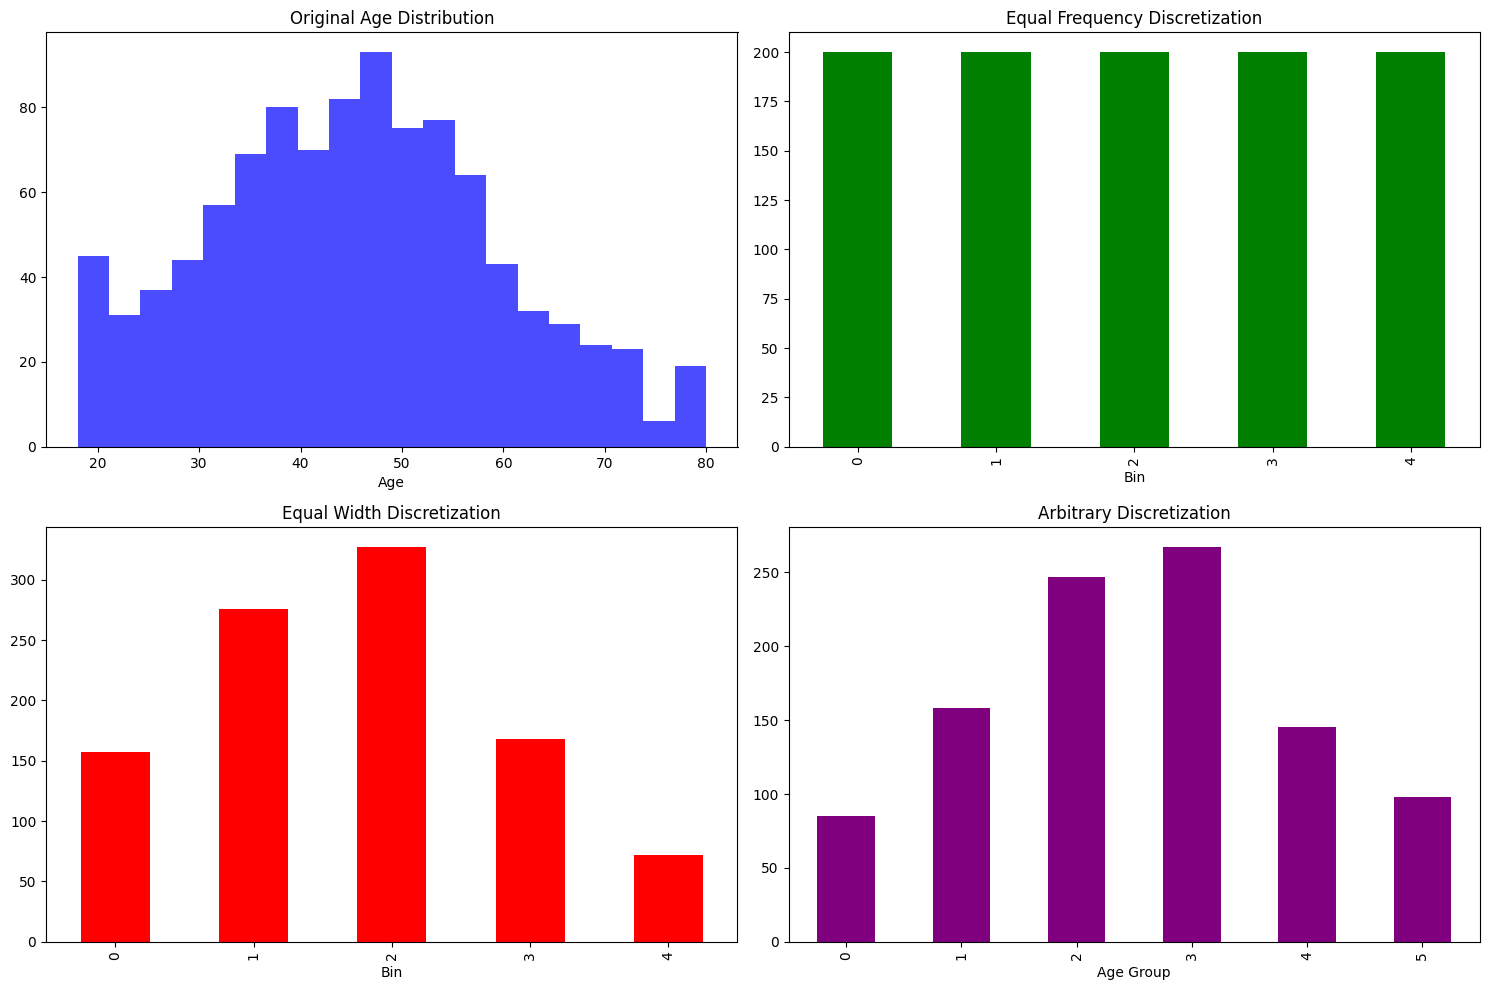

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original distribution
axes[0,0].hist(df['age'], bins=20, alpha=0.7, color='blue')
axes[0,0].set_title('Original Age Distribution')
axes[0,0].set_xlabel('Age')

# Equal Frequency
df_freq['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='green')
axes[0,1].set_title('Equal Frequency Discretization')
axes[0,1].set_xlabel('Bin')

# Equal Width  
df_width['age'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='red')
axes[1,0].set_title('Equal Width Discretization')
axes[1,0].set_xlabel('Bin')

# Arbitrary
df_arb['age'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Arbitrary Discretization')
axes[1,1].set_xlabel('Age Group')

plt.tight_layout()
plt.show()

In [ ]:
#Topic 6: Handle Outlier

import pandas as pd
import numpy as np
from feature_engine.outliers import Winsorizer, ArbitraryOutlierCapper, OutlierTrimmer

# Create realistic data with outliers
np.random.seed(42)
n_samples = 1000

# Normal data with some outliers
heights = np.random.normal(170, 10, n_samples)
heights = np.append(heights, [250, 50, 300])  # Add impossible heights

weights = np.random.normal(70, 15, n_samples) 
weights = np.append(weights, [500, 10, 600])  # Add impossible weights

df = pd.DataFrame({
    'height_cm': heights,
    'weight_kg': weights
})

print("Original Data Summary:")
print(df.describe())

# Method 1: Winsorizer (IQR method)
print("\n--- METHOD 1: Winsorizer (IQR Capping) ---")
winsorizer = Winsorizer(capping_method='iqr', tail='both', fold=1.5)
df_winsorized = winsorizer.fit_transform(df)
print("After Winsorizer:")
print(df_winsorized.describe())
print(f"Capping limits: {winsorizer.right_tail_caps_}")

# Method 2: Arbitrary Capping (Domain Knowledge)
print("\n--- METHOD 2: Arbitrary Capping ---")
# Define MIN and MAX limits separately
min_limits = {
    'height_cm': 100,  # Minimum acceptable height
    'weight_kg': 30    # Minimum acceptable weight
}

max_limits = {
    'height_cm': 220,  # Maximum acceptable height  
    'weight_kg': 200   # Maximum acceptable weight
}

arbitrary_capper = ArbitraryOutlierCapper(
    max_capping_dict=max_limits,    # Maximum boundaries
    min_capping_dict=min_limits     # Minimum boundaries
)
#arb_capper = ArbitraryOutlierCapper(max_capping_dict=arbitrary_limits)
df_arbitrary = arbitrary_capper.fit_transform(df)
print("After Arbitrary Capping:")
print(df_arbitrary.describe())

# Method 3: Trimming (Remove Outliers)
print("\n--- METHOD 3: Outlier Trimming ---")
trimmer = OutlierTrimmer(capping_method='iqr', tail='both', fold=3)  # More conservative
df_trimmed = trimmer.fit_transform(df)
print("After Trimming:")
print(df_trimmed.describe())
print(f"Rows removed: {len(df) - len(df_trimmed)}")

Original Data Summary:
         height_cm    weight_kg
count  1003.000000  1003.000000
mean    170.282473    71.956674
std      11.540428    26.247726
min      50.000000    10.000000
25%     163.513923    60.898473
50%     170.260911    70.967116
75%     176.494555    81.006384
max     300.000000   600.000000

--- METHOD 1: Winsorizer (IQR Capping) ---
After Winsorizer:
         height_cm    weight_kg
count  1003.000000  1003.000000
mean    170.207952    71.111805
std       9.796656    15.001781
min     144.042974    30.736607
25%     163.513923    60.898473
50%     170.260911    70.967116
75%     176.494555    81.006384
max     195.965504   111.168250
Capping limits: {'height_cm': 195.96550421958648, 'weight_kg': 111.16825017482611}

--- METHOD 2: Arbitrary Capping ---
After Arbitrary Capping:
         height_cm    weight_kg
count  1003.000000  1003.000000
mean    170.222653    71.296385
std      10.269723    16.015100
min     100.000000    30.000000
25%     163.513923    60.898473
50